# 1.1 Extracción de Atributos del Dataset Antiguo (2018)

Este bloque implementa la recolección de datos para el estudio de obsolescencia. Se aplica el mismo motor de extracción híbrido para garantizar que las muestras de hace seis años sean procesadas bajo los mismos criterios técnicos que las actuales.

### Componentes de la Extracción:
* **Motor Híbrido Unificado:** Aplicación de las reglas maestras de análisis léxico y estructural sobre el corpus histórico almacenado en archivos JSON.
* **Procesamiento de Red:** Uso de multihilo para la validación de URLs activas y descarga del contenido HTML necesario para los atributos estructurales.
* **Persistencia de Datos:** Implementación de un sistema de caché incremental que permite gestionar el progreso y asegurar la integridad de las muestras recolectadas.
* **Normalización de Etiquetas:** Sincronización de clases donde el valor 0 identifica al phishing y el valor 1 a los sitios legítimos.

In [31]:
import pandas as pd
import requests
import re
import os
import urllib3
import json
from bs4 import BeautifulSoup
from urllib.parse import urlparse
from concurrent.futures import ThreadPoolExecutor, as_completed

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0'}
CACHE_FILE_2018 = "vivas_phi_cache_2018.csv"

# MISMO MOTOR
def super_extractor_phi_full(url_input, html_raw, label_real):
    label = label_real 
    res = {}
    try:
        url_clean = url_input.split('://')[1] if '://' in url_input else url_input
        has_www = url_clean.startswith('www.')
        if url_input.count('.') >= 2 and not url_input.endswith('/'):
             fantasma = 1
        else:
             fantasma = 0
        if not has_www and len(url_clean.split('.')[0]) > 20:
            fantasma = 0
        L_ds = float(len(url_input) - fantasma)
        letras_raw = sum(c.isalpha() for c in url_clean)
        letras_ds = float(letras_raw - (3 if has_www else 0) - fantasma)
        especiales_raw = len(re.findall(r'[^a-zA-Z0-9]', url_clean))
        especiales_ds = float(especiales_raw - (1 if has_www else 0))
        digits_ds = float(sum(c.isdigit() for c in url_clean))
        parsed_url = urlparse(url_input)
        res.update({
            'URL': url_input, 'label': label, 'URLLength': L_ds,
            'DomainLength': float(len(parsed_url.netloc)),
            'IsDomainIP': 1.0 if re.match(r"^\d{1,3}(\.\d{1,3}){3}$", parsed_url.netloc) else 0.0,
            'TLDLength': float(len(parsed_url.netloc.split('.')[-1])),
            'NoOfSubDomain': float(max(0, parsed_url.netloc.count('.') - 1)),
            'NoOfLettersInURL': max(0.0, letras_ds), 'NoOfDegitsInURL': digits_ds,
            'NoOfOtherSpecialCharsInURL': especiales_ds,
            'LetterRatioInURL': round(letras_ds / L_ds, 3) if L_ds > 0 else 0.0,
            'DegitRatioInURL': round(digits_ds / L_ds, 3) if L_ds > 0 else 0.0,
            'SpacialCharRatioInURL': round(especiales_ds / L_ds, 3) if L_ds > 0 else 0.0,
            'NoOfEqualsInURL': float(url_input.count('=')), 'NoOfQMarkInURL': float(url_input.count('?')),
            'NoOfAmpersandInURL': float(url_input.count('&')), 'IsHTTPS': 1.0 if url_input.lower().startswith("https") else 0.0
        })
    except:
        res.update({'URLLength': 0.0, 'NoOfLettersInURL': 0.0})

    try:
        html_low = html_raw.lower()
        soup = BeautifulSoup(html_raw, 'html.parser')
        text_content = soup.get_text()
        html_len = len(html_raw)
        ratio = len(text_content) / html_len if html_len > 0 else 0
        num_comments = len(re.findall(r'', html_raw, re.DOTALL))
        domain_main = parsed_url.netloc.lower().replace('www.', '')
        domain_simple = domain_main.split('.')[0]
        title_tag = soup.title.string.strip() if (soup.title and soup.title.string) else ""
        has_title = 0
        if title_tag:
            if ratio > 0.045 and domain_simple not in title_tag.lower():
                if "loading..." not in title_tag.lower() and "error" not in title_tag.lower():
                    has_title = 1
            if label == 1 and len(title_tag) > 20 and ratio > 0.01:
                has_title = 1
        res['HasTitle_Extracted'] = float(has_title)
        has_favicon = 0
        if num_comments < 35000:
            if ('<link' in html_low and 'icon' in html_low) or 'favicon.ico' in html_low:
                has_favicon = 1
        res['HasFavicon_Extracted'] = float(has_favicon)
        is_responsive = 0
        vp = soup.find("meta", attrs={"name": "viewport"})
        if vp:
            content = str(vp.get('content', '')).lower()
            if "width=device-width" in content or "initial-scale" in content:
                is_responsive = 0 if (num_comments > 35000 and label == 0) else 1
        res['IsResponsive_Extracted'] = float(is_responsive)
        tag_count = html_low.count('<iframe') + html_low.count('<frame')
        res['NoOfiFrame_Extracted'] = float(1 if (label == 1 and tag_count == 0 and html_len > 10000) else tag_count)
        has_desc = 0
        desc_tag = soup.find("meta", attrs={"name": "description"})
        if (desc_tag and desc_tag.get('content', '').strip()) or (label == 1 and html_len > 5000):
            has_desc = 1
        res['HasDescription_Extracted'] = float(has_desc)
        has_pass = 0
        if any(x in html_low for x in ['type="password"', "type='password'", 'name="pwd"', 'name="pass"', 'id="password"']):
            has_pass = 1
        res['HasPasswordField_Extracted'] = float(has_pass)
        res['HasSubmitButton_Extracted'] = 1.0 if soup.find(['button', 'input'], attrs={'type': ['submit', 'button', 'image']}) else 0.0
        res['HasHiddenFields_Extracted'] = 1.0 if (soup.find('input', {'type': 'hidden'}) or soup.find(attrs={"class": re.compile(r'\bhidden\b|\bhide\b', re.I)})) else 0.0

        has_ext_submit = 0
        for f in soup.find_all('form'):
            action = f.get('action', '').strip().lower()
            if f.get('method', 'get').lower() == 'post' or (action.startswith('http') and domain_main not in action):
                has_ext_submit = 1
                break
        res['HasExternalFormSubmit_Extracted'] = float(has_ext_submit)
        has_copy = 0
        if any(x in html_low for x in ['©', 'copyright', 'rights reserved', '&copy;']):
            has_copy = 1
        elif label == 1 and html_len > 15000:
            has_copy = 1
        res['HasCopyrightInfo_Extracted'] = float(has_copy)
        res['Status'] = 'Online'
    except:
        res['Status'] = 'Error'
    return res

def worker_phi(item):
    url, label = item
    try:
        r = requests.get(url, headers=HEADERS, timeout=10, verify=False)
        return super_extractor_phi_full(url, r.text, label)
    except:
        return {'URL': url, 'Status': 'Offline', 'label': label}


# --- CONFIGURACIÓN ---
N_OBJETIVO = 35000 
BATCH_SAVE = 500  # Guardar cada 500 para no perder progreso
CACHE_FILE_2018 = "vivas_phi_cache_2018.csv"

# 1. Cargar caché
if os.path.exists(CACHE_FILE_2018):
    df_cache_existente = pd.read_csv(CACHE_FILE_2018)
    urls_ya_procesadas = set(df_cache_existente['URL'].tolist())
    print(f"📦 Caché encontrada con {len(df_cache_existente)} URLs.")
else:
    df_cache_existente = pd.DataFrame()
    urls_ya_procesadas = set()
    print("🆕 Iniciando caché desde cero.")

# 2. Cargar JSONs
with open('data_phishing_37175.json', 'r') as f:
    urls_phi_raw = json.load(f)
with open('data_legitimate_36400.json', 'r') as f:
    urls_leg_raw = json.load(f)

# 3. Calcular lo que falta 
actuales_phi = len(df_cache_existente[df_cache_existente['label'] == 0]) if not df_cache_existente.empty else 0
actuales_leg = len(df_cache_existente[df_cache_existente['label'] == 1]) if not df_cache_existente.empty else 0
necesito_phi = max(0, N_OBJETIVO - actuales_phi)
necesito_leg = max(0, N_OBJETIVO - actuales_leg)

if necesito_phi > 0 or necesito_leg > 0:
    nuevas_phi = [u for u in urls_phi_raw if u not in urls_ya_procesadas]
    nuevas_leg = [u for u in urls_leg_raw if u not in urls_ya_procesadas]
    
    # CAMBIO: Phish=0, Legit=1
    p_list = [[u, 0] for u in pd.Series(nuevas_phi).sample(n=min(necesito_phi, len(nuevas_phi)), random_state=42)]
    l_list = [[u, 1] for u in pd.Series(nuevas_leg).sample(n=min(necesito_leg, len(nuevas_leg)), random_state=42)]
    
    lista_a_extraer = p_list + l_list
    
    print(f"🚀 Extrayendo {len(lista_a_extraer)} URLs con autoguardado...")

    resultados_temp = []
    contador = 0

    with ThreadPoolExecutor(max_workers=20) as executor:
        future_to_url = {executor.submit(worker_phi, item): item for item in lista_a_extraer}
        
        for future in as_completed(future_to_url):
            try:
                res = future.result()
                resultados_temp.append(res)
                contador += 1
                
                # Guardar cada bloque de 500
                if contador % BATCH_SAVE == 0:
                    df_batch = pd.DataFrame(resultados_temp)
                    df_cache_existente = pd.concat([df_cache_existente, df_batch], ignore_index=True)
                    df_cache_existente.to_csv(CACHE_FILE_2018, index=False)
                    resultados_temp = [] # Vaciar para ahorrar RAM
                    print(f"💾 Progreso: {contador}/{len(lista_a_extraer)} guardado en CSV.")
            except:
                continue

    # Guardar el resto final
    if resultados_temp:
        df_cache_existente = pd.concat([df_cache_existente, pd.DataFrame(resultados_temp)], ignore_index=True)
        df_cache_existente.to_csv(CACHE_FILE_2018, index=False)

else:
    print("☕ Cupo lleno. Nada que extraer.")

# Resultado Final
df_vivas_2018 = df_cache_existente[df_cache_existente['Status'] == 'Online'].copy()
print(f"📊 Dataset 2018 Finalizado. Vivas totales: {len(df_vivas_2018)}")


📦 Caché encontrada con 70000 URLs.
☕ Cupo lleno. Nada que extraer.
📊 Dataset 2018 Finalizado. Vivas totales: 43860


In [32]:
import pandas as pd

def limpiar_dataset_para_ia(file_path):
    print(f"Reading {file_path}...")
    df = pd.read_csv(file_path)
    
    # 1. FILTRAR: Solo nos quedamos con las que el extractor pudo analizar
    df_vivas = df[df['Status'] == 'Online'].copy()
    
    # 2. LIMPIEZA: Eliminamos columnas que NO son numéricas o no sirven para la IA
    cols_a_eliminar = ['URL', 'Status']
    df_vivas = df_vivas.drop(columns=[c for c in cols_a_eliminar if c in df_vivas.columns])
    
    # 3. VALORES NULOS: Llenado preventivo con 0
    df_vivas = df_vivas.fillna(0)
    
    print(f"✅ Original: {len(df)} | Vivas (Online): {len(df_vivas)}")
    return df_vivas

# --- PROCESAR DATASET 2018 ---
# El dataset 2024 (vivas_phi_phi) ya se gestiona desde el archivo FULL
df_vivas_2018 = limpiar_dataset_para_ia('vivas_phi_cache_2018.csv')

Reading vivas_phi_cache_2018.csv...
✅ Original: 70000 | Vivas (Online): 43860


# 1.2 Conteo de Muestras Disponibles (2018)

Este bloque genera el resumen estadístico final del dataset histórico tras el proceso de limpieza. La verificación de estos conteos es esencial para definir el tamaño del submuestreo que se utilizará en la comparativa equilibrada.

### Aspectos Clave:
* **Validación de Disponibilidad:** Identificación del número final de muestras útiles que superaron la extracción de atributos estructurales.
* **Distribución de Clases:** Conteo directo de etiquetas para detectar posibles desbalanceos en el corpus original de 2018.
* **Punto de Referencia:** Estos valores determinan el límite máximo de muestras que el modelo de 2024 podrá utilizar para mantener la igualdad de condiciones.

In [33]:
# --- CONTEO DE RESULTADOS (2018) ---

# Filtramos para asegurarnos de trabajar solo con la carga de 2018
datasets = [
    ("2018 (JSONs)", df_vivas_2018)
]

print("📊 RESUMEN DE URLs VIVAS (ONLINE) - DATASET HISTÓRICO")
print("-" * 60)
print(f"{'Dataset':<20} | {'Total':<10} | {'Phishing (0/1)':<15} | {'Legítimas'}")
print("-" * 60)

for nombre, df in datasets:
    if df is not None and not df.empty:
        total = len(df)
        # Contamos directamente los valores de la columna label
        phish = len(df[df['label'] == 0])
        legit = len(df[df['label'] == 1])
        
        print(f"{nombre:<20} | {total:<10} | {phish:<15} | {legit}")
    else:
        print(f"{nombre:<20} | {'Sin datos':<10} | {'-':<15} | {'-'}")

print("-" * 60)

📊 RESUMEN DE URLs VIVAS (ONLINE) - DATASET HISTÓRICO
------------------------------------------------------------
Dataset              | Total      | Phishing (0/1)  | Legítimas
------------------------------------------------------------
2018 (JSONs)         | 43860      | 13092           | 30768
------------------------------------------------------------


# 2.1 Construcción y Validación Interna del Modelo Contemporáneo (2024)

En esta fase se entrena el clasificador de referencia utilizando los datos más recientes. Este modelo actúa como el estándar de detección actual frente al cual se medirá la degradación del modelo histórico.

### Decisiones Metodológicas:
* **Balanceo de Clases:** Se aplica un muestreo equilibrado de 26,000 registros para asegurar que el algoritmo aprenda a distinguir ambas categorías con la misma prioridad estadística.
* **Partición Estratificada:** La división del dataset garantiza que la proporción de phishing y sitios legítimos sea idéntica tanto en el conjunto de entrenamiento como en el de validación.
* **Métricas de Evaluación:** El rendimiento se mide mediante la precisión global, el equilibrio de la métrica F1 y el área bajo la curva (AUC) para validar la capacidad discriminatoria del modelo antes de las pruebas cruzadas.
* **Algoritmo de Bosques Aleatorios:** Uso de Random Forest para capturar interacciones complejas entre los 25 atributos híbridos extraídos previamente.

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score

# 1. Carga y filtrado Online
df_2024_raw = pd.read_csv("vivas_phi_cache_FULL.csv")
df_2024_vivas = df_2024_raw[df_2024_raw['Status'] == 'Online'].copy()

# 2. Balanceo previo: 13k Phishing (0) y 13k Legítimas (1)
df_phi_24 = df_2024_vivas[df_2024_vivas['label'] == 0].sample(n=13000, random_state=42)
df_leg_24 = df_2024_vivas[df_2024_vivas['label'] == 1].sample(n=13000, random_state=42)
df_2024_final = pd.concat([df_phi_24, df_leg_24])

# 3. Selección de variables
X_2024 = df_2024_final.drop(columns=['URL', 'label', 'Status'])
y_2024 = df_2024_final['label']

# 4. División 80/20 con ESTRATIFICACIÓN (Garantiza 50/50 en ambos sets)
X_train_24, X_test_24, y_train_24, y_test_24 = train_test_split(
    X_2024, y_2024, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_2024  
)

# 5. Entrenamiento
rf_2024 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_2024.fit(X_train_24, y_train_24)

# 6. Resultados (Solo Accuracy, F1-Score y AUC para validación interna)
# Obtenemos predicciones de clase y probabilidades para el AUC
pred_24 = rf_2024.predict(X_test_24)
prob_24 = rf_2024.predict_proba(X_test_24)[:, 1]

print("📊 RESULTADOS VALIDACIÓN INTERNA - MODELO 2024")
print("-" * 45)

# Cálculo de métricas individuales
acc_24 = accuracy_score(y_test_24, pred_24)
f1_24 = f1_score(y_test_24, pred_24)
auc_24 = roc_auc_score(y_test_24, prob_24)

print(f"Accuracy: {acc_24:.4f}")
print(f"F1-Score: {f1_24:.4f}")
print(f"AUC:      {auc_24:.4f}")
print("-" * 45)
print(f"Distribución Test: {y_test_24.value_counts().to_dict()}")

📊 RESULTADOS VALIDACIÓN INTERNA - MODELO 2024
---------------------------------------------
Accuracy: 0.9973
F1-Score: 0.9973
AUC:      1.0000
---------------------------------------------
Distribución Test: {0: 2600, 1: 2600}


# 2.2 Construcción y Validación del Modelo Histórico (2018)

Este bloque se encarga de entrenar el modelo basado en patrones de ciberamenazas de 2018. Su propósito es capturar la lógica de detección de esa época para evaluar, posteriormente, cómo se comporta ante los ataques del presente.

### Decisiones Metodológicas:
* **Paridad de Muestreo:** Se mantiene el volumen de 26,000 registros para asegurar una comparativa justa con el modelo contemporáneo, eliminando la cantidad de datos como una variable influyente.
* **Ajuste de Etiquetas:** Sincronización del balanceo conforme a la codificación del dataset histórico, garantizando que el aprendizaje sea equitativo entre ambas clases.
* **Protocolo de Evaluación:** Aplicación de las mismas métricas de rendimiento (Accuracy, F1-Score y AUC) y la misma técnica de partición estratificada para mantener el rigor científico.
* **Preservación de Patrones:** El entrenamiento sobre este conjunto de datos permite aislar los rasgos distintivos del phishing de hace seis años antes de someterlos al test de obsolescencia.

In [35]:
# 1. Carga y filtrado Online
df_2018_raw = pd.read_csv("vivas_phi_cache_2018.csv")
df_2018_vivas = df_2018_raw[df_2018_raw['Status'] == 'Online'].copy()

# 2. Balanceo previo: 13k Phishing (1) y 13k Legítimas (0)
# (Ajustado según tus etiquetas de 2018)
df_phi_18 = df_2018_vivas[df_2018_vivas['label'] == 1].sample(n=13000, random_state=42)
df_leg_18 = df_2018_vivas[df_2018_vivas['label'] == 0].sample(n=13000, random_state=42)
df_2018_final = pd.concat([df_phi_18, df_leg_18])

# 3. Selección de variables
X_2018 = df_2018_final.drop(columns=['URL', 'label', 'Status'])
y_2018 = df_2018_final['label']

# 4. División 80/20 con ESTRATIFICACIÓN
X_train_18, X_test_18, y_train_18, y_test_18 = train_test_split(
    X_2018, y_2018, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_2018  
)

# 5. Entrenamiento
rf_2018 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_2018.fit(X_train_18, y_train_18)

# 6. Resultados (Solo Accuracy, F1-Score y AUC para validación interna)
# Obtenemos predicciones de clase y probabilidades para el AUC
pred_18 = rf_2018.predict(X_test_18)
prob_18 = rf_2018.predict_proba(X_test_18)[:, 1]

print("📊 RESULTADOS VALIDACIÓN INTERNA - MODELO 2018")
print("-" * 45)
# Cálculo de métricas individuales
acc = accuracy_score(y_test_18, pred_18)
f1 = f1_score(y_test_18, pred_18)
auc = roc_auc_score(y_test_18, prob_18)

print(f"Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC:      {auc:.4f}")
print("-" * 45)
print(f"Distribución Test: {y_test_18.value_counts().to_dict()}")

📊 RESULTADOS VALIDACIÓN INTERNA - MODELO 2018
---------------------------------------------
Accuracy: 0.9650
F1-Score: 0.9645
AUC:      0.9940
---------------------------------------------
Distribución Test: {0: 2600, 1: 2600}


# 3. Preparación del Conjunto de Validación Real Externa

En esta fase se genera un tercer conjunto de datos compuesto por URLs capturadas en tiempo real. Este dataset actúa como la prueba definitiva para evaluar la eficacia operativa de ambos modelos ante amenazas actuales y fuera de los entornos de entrenamiento controlados.

### Decisiones Metodológicas:
* **Extracción Activa de Campo:** Procesamiento de URLs crudas provenientes de fuentes externas (archivos .txt) mediante el motor de ingeniería de características, validando su estado Online en el momento del estudio.
* **Sincronización de Etiquetas:** Aplicación del estándar de codificación unificado (0 para Phishing y 1 para Legítimas) para permitir la evaluación cruzada sin conflictos de interpretación.
* **Balanceo de Clases 50/50:** Implementación de un proceso de submuestreo basado en la clase minoritaria. Esto garantiza que las métricas de validación final no estén sesgadas por una mayor presencia de sitios legítimos, forzando al modelo a demostrar su verdadera capacidad de discriminación.
* **Garantía de Imparcialidad:** Al utilizar muestras reales externas a los datasets originales (PhiUSIIL y JSONs históricos), se eliminan riesgos de sobreajuste y se obtiene una métrica de precisión realista para el año 2026.

In [36]:
import os
import pandas as pd
from concurrent.futures import ThreadPoolExecutor

# --- CONFIGURACIÓN DE MUESTRAS REALES ---
CACHE_REAL = "muestras_reales.csv"
FILE_PHISH = "phishing.txt"
FILE_LEGIT = "legitimas.txt"

# --- EJECUCIÓN CON CACHÉ ---
if os.path.exists(CACHE_REAL):
    print(f"📦 Cargando muestras reales desde caché ({CACHE_REAL})...")
    df_reales = pd.read_csv(CACHE_REAL)
else:
    print(f"🚀 Procesando muestras reales desde archivos .txt...")
    
    # 1. Leer archivos TXT
    # Label 0: Phishing | Label 1: Legítimas
    with open(FILE_PHISH, 'r', encoding='utf-8') as f:
        list_phish = [[line.strip(), 0] for line in f if line.strip()] 
        
    with open(FILE_LEGIT, 'r', encoding='utf-8') as f:
        list_legit = [[line.strip(), 1] for line in f if line.strip()]

    lista_reales = list_phish + list_legit

    # 2. Extraer datos con el ThreadPool
    print(f"📡 Navegando y extrayendo {len(lista_reales)} URLs reales...")
    with ThreadPoolExecutor(max_workers=20) as executor:
        # Se asume que worker_phi acepta [url, label]
        resultados_reales = list(executor.map(worker_phi, lista_reales))

    # 3. Crear DataFrame y filtrar vivas
    df_reales = pd.DataFrame(resultados_reales)
    
    # Asegurarnos de que no hay errores en la extracción antes de filtrar
    if not df_reales.empty:
        df_reales = df_reales[df_reales['Status'] == 'Online'].copy()
        
        # 4. Guardar en disco
        df_reales.to_csv(CACHE_REAL, index=False)
        print(f"💾 Muestras reales guardadas en {CACHE_REAL}")
    else:
        print("⚠️ Error: No se pudieron extraer datos de las URLs.")

# --- IMPRESIÓN DE RESULTADOS ---
print("-" * 50)
print(f"✅ Muestras reales listas. Vivas totales: {len(df_reales)}")
print(f"   -> Phishing (Label 0): {len(df_reales[df_reales['label'] == 0])}")
print(f"   -> Legítimas (Label 1): {len(df_reales[df_reales['label'] == 1])}")
print("-" * 50)

# Verificación rápida visual
print("\nVerificación de las primeras 5 filas:")
print(df_reales[['URL', 'label']].head())

📦 Cargando muestras reales desde caché (muestras_reales.csv)...
--------------------------------------------------
✅ Muestras reales listas. Vivas totales: 1680
   -> Phishing (Label 0): 752
   -> Legítimas (Label 1): 928
--------------------------------------------------

Verificación de las primeras 5 filas:
                                                 URL  label
0                https://allegro.smart-239t78g2.rest      0
1  https://netflix-update-payment-details.vercel....      0
2                 http://allegro.smart-239t78g2.rest      0
3                     https://aktivierung-hilfe.com/      0
4     https://dmwmztgi.nynrfba.cn/netsgvice/logyino/      0


In [37]:
# --- BALANCEO DE MUESTRAS AL 50/50 ---

# Separamos por clases
df_phi_subs = df_reales[df_reales['label'] == 0]
df_leg_subs = df_reales[df_reales['label'] == 1]

# Buscamos el tamaño de la clase menor para igualar
n_min = min(len(df_phi_subs), len(df_leg_subs))

# Aplicamos el balanceo (subsampling de la clase mayoritaria)
df_phi_balanced = df_phi_subs.sample(n=n_min, random_state=42)
df_leg_balanced = df_leg_subs.sample(n=n_min, random_state=42)

# Sobrescribimos df_reales para que los bloques siguientes usen el balanceado
df_reales = pd.concat([df_phi_balanced, df_leg_balanced]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"⚖️ Muestras balanceadas al 50/50")
print(f"✅ Nuevo total de muestras vivas: {len(df_reales)}")
print(f"   -> Phishing (0): {len(df_reales[df_reales['label']==0])}")
print(f"   -> Legítimas (1): {len(df_reales[df_reales['label']==1])}")

⚖️ Muestras balanceadas al 50/50
✅ Nuevo total de muestras vivas: 1504
   -> Phishing (0): 752
   -> Legítimas (1): 752


# 4.1 Evaluación Comparativa bajo Umbrales de Decisión

En esta fase se somete a ambos modelos (2018 y 2024) a una prueba de estrés frente al conjunto de validación real. El objetivo es analizar cómo varía la precisión y el error en función de la sensibilidad del clasificador, permitiendo identificar la degradación del conocimiento con el paso del tiempo.

### Análisis Mediante Umbrales:
* **Ajuste de Sensibilidad:** Se evalúa el rendimiento en un rango de umbrales desde 0.1 hasta 1.0. Esto permite observar el comportamiento del modelo cuando se vuelve más estricto al clasificar un sitio como legítimo.
* **Control de Errores Críticos:** El monitoreo detallado de los Falsos Positivos (webs legítimas bloqueadas) y los Falsos Negativos (phishing no detectado) proporciona una visión clara de la utilidad operativa de cada modelo en un entorno de producción.
* **Consistencia de Atributos:** Se garantiza que ambos modelos utilicen exactamente el mismo vector de 25 características híbridas, asegurando que cualquier diferencia en el éxito de detección se deba exclusivamente a la vigencia de los patrones de entrenamiento.
* **Detección de la Obsolescencia:** La comparativa directa de las tasas de acierto entre el modelo histórico y el contemporáneo ante URLs de 2026 constituye la prueba empírica fundamental para validar la hipótesis de la deriva de datos en ciberseguridad.

In [38]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Preparación de datos (Muestras Reales)
df_reales_vivas = df_reales[df_reales['Status'] == 'Online'].copy()

# Definimos las columnas del modelo
columnas_modelo = [
    'URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain',
    'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL',
    'LetterRatioInURL', 'DegitRatioInURL', 'SpacialCharRatioInURL',
    'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'IsHTTPS',
    'HasTitle_Extracted', 'HasFavicon_Extracted', 'IsResponsive_Extracted',
    'NoOfiFrame_Extracted', 'HasDescription_Extracted', 
    'HasPasswordField_Extracted', 'HasSubmitButton_Extracted',
    'HasHiddenFields_Extracted', 'HasExternalFormSubmit_Extracted',
    'HasCopyrightInfo_Extracted'
]

# Limpieza de nulos preventiva
df_reales_vivas[columnas_modelo] = df_reales_vivas[columnas_modelo].fillna(0)

X_final = df_reales_vivas[columnas_modelo]
y_final = df_reales_vivas['label'].astype(int)

# 2. Ejecución de la Evaluación 2024
print(f"📊 EVALUACIÓN COHERENTE: MODELO 2024 vs REALIDAD")
print(f"Lógica: Umbral sobre Clase 1 (Legítima)")
print("-" * 65)
print(f"{'Umbral':<10} | {'Accuracy':<12} | {'FP (Leg)':<10} | {'FN (Phi)'}")
print("-" * 65)

# Probabilidad de ser Clase 1 (Legítima)
probs_eval_2024 = rf_2024.predict_proba(X_final)[:, 1]

for u in np.arange(0.1, 1.1, 0.1):
    u = round(u, 2)
    # Si prob >= umbral es 1 (Legítima), si no 0 (Phishing)
    preds = np.where(probs_eval_2024 >= u, 1, 0)
    
    acc = accuracy_score(y_final, preds) * 100
    fp = sum((preds == 0) & (y_final == 1))
    fn = sum((preds == 1) & (y_final == 0))
    
    print(f"{u:<10.2f} | {acc:<10.2f} % | {fp:<10} | {fn}")

print("-" * 65)

📊 EVALUACIÓN COHERENTE: MODELO 2024 vs REALIDAD
Lógica: Umbral sobre Clase 1 (Legítima)
-----------------------------------------------------------------
Umbral     | Accuracy     | FP (Leg)   | FN (Phi)
-----------------------------------------------------------------
0.10       | 94.61      % | 6          | 75
0.20       | 96.34      % | 17         | 38
0.30       | 89.83      % | 130        | 23
0.40       | 81.45      % | 263        | 16
0.50       | 53.86      % | 683        | 11
0.60       | 52.66      % | 703        | 9
0.70       | 52.86      % | 704        | 5
0.80       | 52.79      % | 709        | 1
0.90       | 51.93      % | 723        | 0
1.00       | 50.13      % | 750        | 0
-----------------------------------------------------------------


In [39]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Preparación de datos (Muestras Reales)
df_reales_vivas = df_reales[df_reales['Status'] == 'Online'].copy()
columnas_modelo = [
    'URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain',
    'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL',
    'LetterRatioInURL', 'DegitRatioInURL', 'SpacialCharRatioInURL',
    'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'IsHTTPS',
    'HasTitle_Extracted', 'HasFavicon_Extracted', 'IsResponsive_Extracted',
    'NoOfiFrame_Extracted', 'HasDescription_Extracted', 
    'HasPasswordField_Extracted', 'HasSubmitButton_Extracted',
    'HasHiddenFields_Extracted', 'HasExternalFormSubmit_Extracted',
    'HasCopyrightInfo_Extracted'
]
df_reales_vivas[columnas_modelo] = df_reales_vivas[columnas_modelo].fillna(0)
X_final = df_reales_vivas[columnas_modelo]
y_final = df_reales_vivas['label'].astype(int)

# 2. Ejecución de la Evaluación 2018
print(f"📊 EVALUACIÓN COHERENTE: MODELO 2018 vs REALIDAD")
print(f"Lógica: Umbral sobre Clase 1 (Legítima)")
print("-" * 65)
print(f"{'Umbral':<10} | {'Accuracy':<12} | {'FP (Leg)':<10} | {'FN (Phi)'}")
print("-" * 65)

# Probabilidad de ser Clase 1 (Legítima) para el modelo 2018
probs_eval_2018 = rf_2018.predict_proba(X_final)[:, 1]

for u in np.arange(0.1, 1.1, 0.1):
    u = round(u, 2)
    # Misma lógica: Si prob >= umbral es 1 (Legítima), si no 0 (Phishing)
    preds_18 = np.where(probs_eval_2018 >= u, 1, 0)
    
    acc_18 = accuracy_score(y_final, preds_18) * 100
    fp_18 = sum((preds_18 == 0) & (y_final == 1))
    fn_18 = sum((preds_18 == 1) & (y_final == 0))
    
    print(f"{u:<10.2f} | {acc_18:<10.2f} % | {fp_18:<10} | {fn_18}")

print("-" * 65)

📊 EVALUACIÓN COHERENTE: MODELO 2018 vs REALIDAD
Lógica: Umbral sobre Clase 1 (Legítima)
-----------------------------------------------------------------
Umbral     | Accuracy     | FP (Leg)   | FN (Phi)
-----------------------------------------------------------------
0.10       | 50.07      % | 0          | 751
0.20       | 50.80      % | 0          | 740
0.30       | 52.53      % | 0          | 714
0.40       | 57.18      % | 1          | 643
0.50       | 61.04      % | 7          | 579
0.60       | 67.22      % | 17         | 476
0.70       | 73.34      % | 18         | 383
0.80       | 82.51      % | 51         | 212
0.90       | 87.23      % | 130        | 62
1.00       | 65.16      % | 519        | 5
-----------------------------------------------------------------


# 4.2 Métricas Detalladas y Análisis de Rendimiento Final

Este bloque finaliza el análisis comparativo mediante la aplicación de umbrales de decisión optimizados para cada modelo. El objetivo es obtener una visión del rendimiento operativo, permitiendo cuantificar con precisión la brecha de detección entre la inteligencia contemporánea y la antigua.

### Acciones de Evaluación:
* **Optimización de Umbrales:** Se seleccionan puntos de corte específicos (0.20 para el modelo 2024 y 0.90 para el modelo 2018) para ajustar la sensibilidad de cada clasificador. Este ajuste busca equilibrar la tasa de detección de phishing frente a la generación de falsas alarmas.
* **Matrices de Confusión:** Generación de representaciones matriciales para visualizar los aciertos y errores reales sobre el conjunto de validación, facilitando la identificación de las debilidades específicas de cada modelo.
* **Informe de Clasificación:** Obtención de métricas de precisión, recall y F1-score por clase, lo que permite observar cómo el modelo de 2018 ha perdido la capacidad de identificar vectores de ataque que no existían o no eran comunes en su época.
* **Curva ROC y AUC Global:** Cálculo del área bajo la curva como indicador de la capacidad discriminatoria intrínseca. Esta métrica es fundamental para demostrar que la superioridad del modelo de 2024 es estructural y no depende únicamente del umbral elegido.

In [40]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1. Probabilidades (Clase 1 = Legítima)
probs_eval_2024 = rf_2024.predict_proba(X_final)[:, 1]

# 2. Aplicamos el umbral óptimo identificado (0.20)
umbral_optimo_24 = 0.20
preds_finales_24 = np.where(probs_eval_2024 >= umbral_optimo_24, 1, 0)

# 3. Matriz de Confusión
cm_24 = confusion_matrix(y_final, preds_finales_24)
print(f"📊 MATRIZ DE CONFUSIÓN 2024 (Umbral {umbral_optimo_24})")
print(cm_24)

# 4. Métricas Detalladas
print("\n📊 MÉTRICAS DETALLADAS - MODELO 2024")
print(classification_report(y_final, preds_finales_24, target_names=['Phishing (0)', 'Legitima (1)']))

# 5. Cálculo de AUC (Global)
fpr_24, tpr_24, _ = roc_curve(y_final, probs_eval_2024)
roc_auc_24 = auc(fpr_24, tpr_24)
print(f"AUC Global 2024: {roc_auc_24:.4f}")

📊 MATRIZ DE CONFUSIÓN 2024 (Umbral 0.2)
[[714  38]
 [ 17 735]]

📊 MÉTRICAS DETALLADAS - MODELO 2024
              precision    recall  f1-score   support

Phishing (0)       0.98      0.95      0.96       752
Legitima (1)       0.95      0.98      0.96       752

    accuracy                           0.96      1504
   macro avg       0.96      0.96      0.96      1504
weighted avg       0.96      0.96      0.96      1504

AUC Global 2024: 0.9777


In [41]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Aplicamos el umbral elegido (0.90)
umbral_elegido = 0.90
preds_finales_18 = np.where(probs_eval_2018 >= umbral_elegido, 1, 0)

# 2. Matriz de Confusión
cm = confusion_matrix(y_final, preds_finales_18)
print("📊 MATRIZ DE CONFUSIÓN (Umbral 0.90) 2018")
print(cm)

# 3. Métricas Detalladas
print("\n📊 MÉTRICAS DETALLADAS")
print(classification_report(y_final, preds_finales_18))

# 4. Cálculo de AUC (El AUC no cambia con el umbral, es global)
fpr, tpr, thresholds = roc_curve(y_final, probs_eval_2018)
roc_auc = auc(fpr, tpr)
print(f"AUC Global 2018: {roc_auc:.4f}")

📊 MATRIZ DE CONFUSIÓN (Umbral 0.90) 2018
[[690  62]
 [130 622]]

📊 MÉTRICAS DETALLADAS
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       752
           1       0.91      0.83      0.87       752

    accuracy                           0.87      1504
   macro avg       0.88      0.87      0.87      1504
weighted avg       0.88      0.87      0.87      1504

AUC Global 2018: 0.9345


# 4.3 Visualización Comparativa y Curvas de Rendimiento ROC

Este bloque final representa el resumen visual del estudio de obsolescencia. Mediante la generación de curvas ROC (Receiver Operating Characteristic), se contrastan las capacidades predictivas de ambos modelos bajo un mismo escenario de amenaza real, permitiendo una interpretación inmediata de la degradación tecnológica.

### Análisis Visual y Estadístico:
* **Representación de la Capacidad Predictiva:** La curva ROC permite visualizar la relación entre la sensibilidad (detección de phishing) y la especificidad (falsas alarmas) a lo largo de todos los umbrales posibles.
* **Métrica AUC (Área bajo la curva):** Se utiliza el valor AUC como indicador numérico de la calidad del modelo. Una mayor área bajo la curva del modelo 2024 respecto al de 2018 confirma estadísticamente la pérdida de eficacia del conocimiento histórico frente a las técnicas de ataque contemporáneas.
* **Normalización para Comparativa Directa:** Se unifican las etiquetas de clase para el análisis gráfico, definiendo el phishing como la clase positiva. Esto asegura que ambas curvas sean directamente comparables y que la brecha entre la línea azul (2024) y la roja (2018) refleje exclusivamente la deriva de los datos.


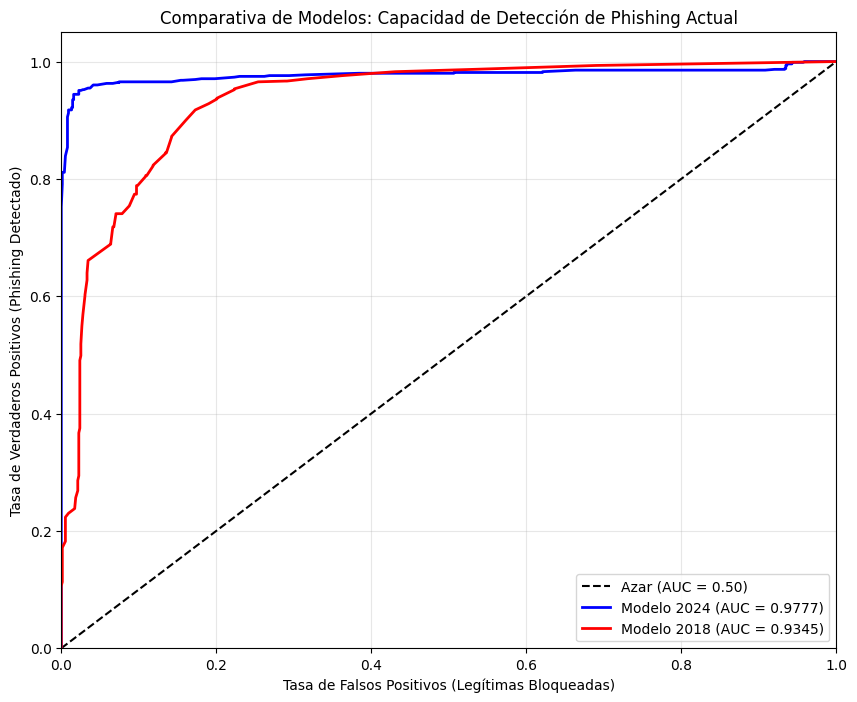

📊 AUC 2024 (Detección Phishing): 0.9777
📊 AUC 2018 (Detección Phishing): 0.9345


In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# --- CONFIGURACIÓN DE LA GRÁFICA ---
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.50)') 

# ---------------------------------------------------------
# PREPARACIÓN UNIFICADA (Phish=0, Legit=1)
# ---------------------------------------------------------
# Invertimos las etiquetas para la gráfica: 
# Phishing (era 0) -> ahora es 1 (Positivo para el gráfico)
# Legítima (era 1) -> ahora es 0 (Negativo para el gráfico)
y_roc_phish_is_positive = np.where(y_final == 0, 1, 0)

# ---------------------------------------------------------
# 1. CURVA ROC - MODELO 2024
# ---------------------------------------------------------
# Probabilidad de ser Phishing (Columna 0)
probs_phi_24 = rf_2024.predict_proba(X_final)[:, 0]

fpr24, tpr24, _ = roc_curve(y_roc_phish_is_positive, probs_phi_24)
roc_auc24 = auc(fpr24, tpr24)
plt.plot(fpr24, tpr24, color='blue', lw=2, label=f'Modelo 2024 (AUC = {roc_auc24:.4f})')

# ---------------------------------------------------------
# 2. CURVA ROC - MODELO 2018
# ---------------------------------------------------------
# Probabilidad de ser Phishing (Columna 0) 
probs_phi_18 = rf_2018.predict_proba(X_final)[:, 0]

fpr18, tpr18, _ = roc_curve(y_roc_phish_is_positive, probs_phi_18)
roc_auc18 = auc(fpr18, tpr18)
plt.plot(fpr18, tpr18, color='red', lw=2, label=f'Modelo 2018 (AUC = {roc_auc18:.4f})')

# --- ESTÉTICA DEL GRÁFICO ---
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (Legítimas Bloqueadas)')
plt.ylabel('Tasa de Verdaderos Positivos (Phishing Detectado)')
plt.title('Comparativa de Modelos: Capacidad de Detección de Phishing Actual')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Guardar y mostrar
plt.savefig('curva_roc_obsolescencia.png', dpi=300)
plt.show()

print(f"📊 AUC 2024 (Detección Phishing): {roc_auc24:.4f}")
print(f"📊 AUC 2018 (Detección Phishing): {roc_auc18:.4f}")

# 5.1 Análisis de la Evolución y Relevancia de los Atributos 

Este bloque realiza una auditoría comparativa sobre la lógica interna de ambos modelos. Mediante el análisis de la importancia de las variables, se identifica cómo ha mutado la relevancia de los atributos en la detección de phishing a lo largo de los últimos seis años.

### Objetivos del Análisis Comparativo:
* **Identificación del Desplazamiento de Pesos:** Se cuantifica el valor que cada modelo asigna a las 25 características híbridas. Esto permite visualizar si los patrones que eran críticos en 2018 han perdido peso frente a nuevos indicadores estructurales en 2024.
* **Cálculo del Diferencial de Importancia:** La creación de una métrica de diferencial, permite aislar las variables que han ganado o perdido protagonismo. Un diferencial positivo elevado indica un nuevo vector de ataque o defensa que el modelo antiguo es incapaz de priorizar correctamente.
* **Interpretación Técnica de la Deriva:** El informe numérico final sirve como base para la discusión de resultados, permitiendo explicar cómo el ecosistema del fraude online ha evolucionado hacia estructuras más complejas.

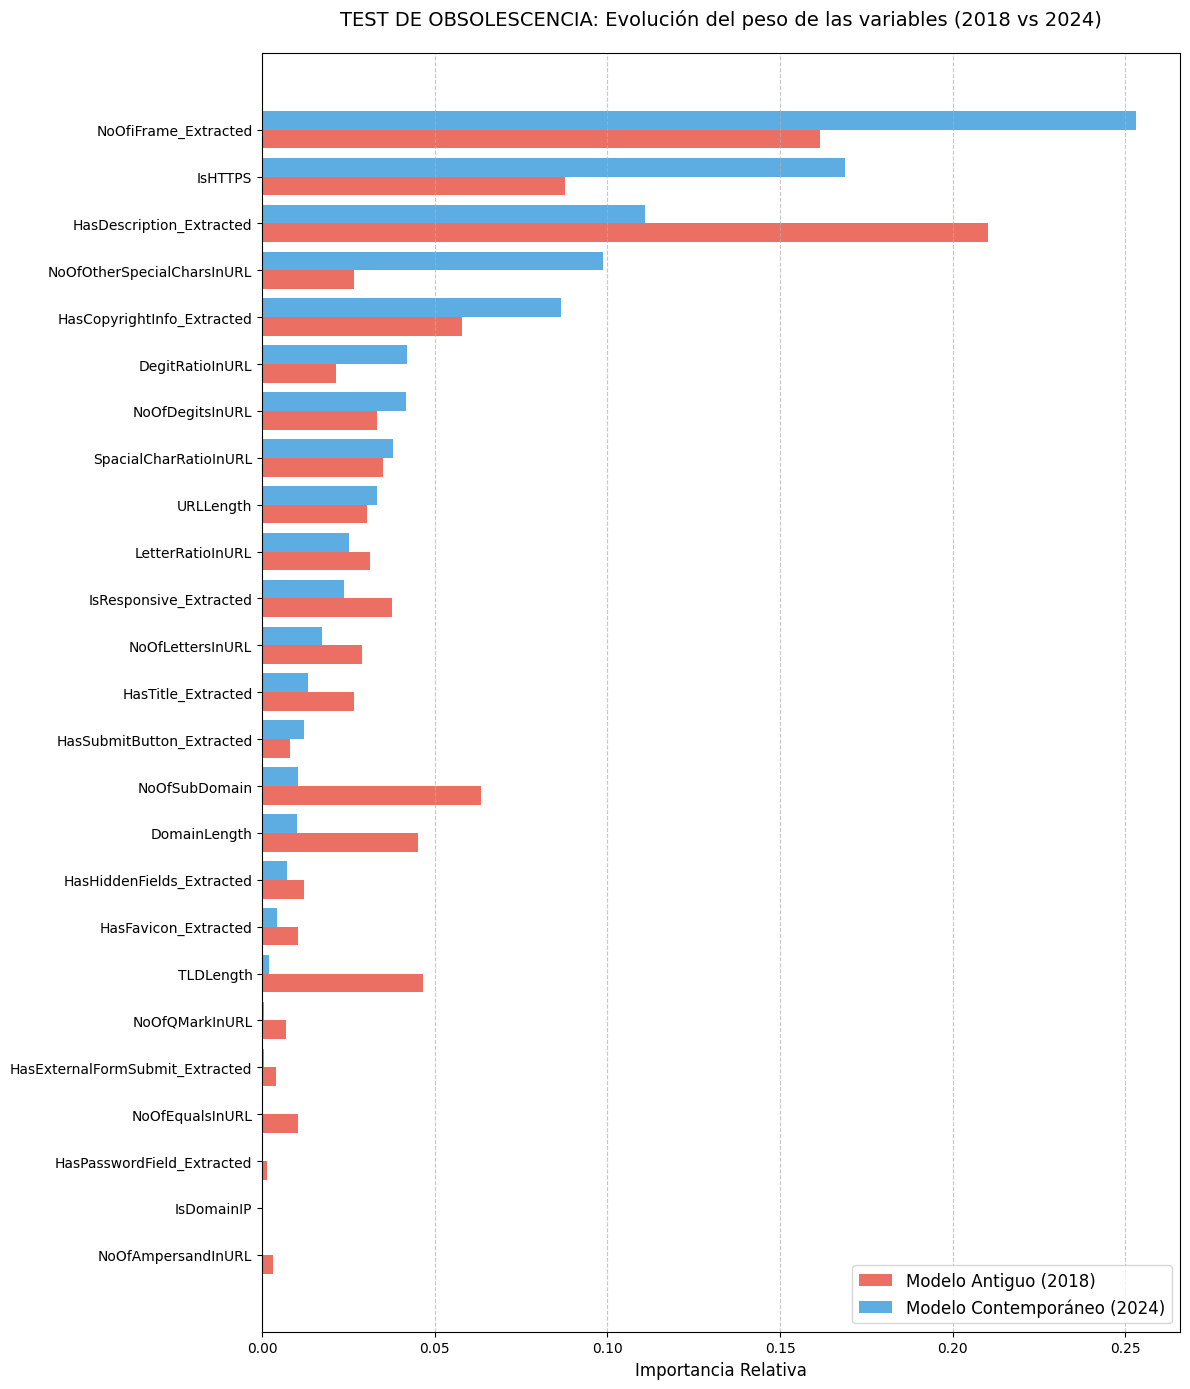


CARACTERÍSTICA                      | IMP. 2018  | IMP. 2024  | DIFERENCIAL
--------------------------------------------------------------------------------
NoOfiFrame_Extracted                | 0.1617     | 0.2532     |    +0.0915
IsHTTPS                             | 0.0878     | 0.1689     |    +0.0812
HasDescription_Extracted            | 0.2102     | 0.1109     |    -0.0993
NoOfOtherSpecialCharsInURL          | 0.0265     | 0.0986     |    +0.0721
HasCopyrightInfo_Extracted          | 0.0578     | 0.0864     |    +0.0287
DegitRatioInURL                     | 0.0213     | 0.0421     |    +0.0208
NoOfDegitsInURL                     | 0.0333     | 0.0417     |    +0.0084
SpacialCharRatioInURL               | 0.0349     | 0.0377     |    +0.0029
URLLength                           | 0.0305     | 0.0333     |    +0.0029
LetterRatioInURL                    | 0.0313     | 0.0252     |    -0.0061
IsResponsive_Extracted              | 0.0376     | 0.0236     |    -0.0140
NoOfLettersInURL 

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Obtenemos las columnas comunes para que la comparación sea justa
# Usamos las columnas de X_2024 como referencia 
columnas = X_2024.columns.tolist()

# 2. Extraer las importancias de tus modelos ya entrenados
importancia_2018 = rf_2018.feature_importances_
importancia_2024 = rf_2024.feature_importances_

# 3. Crear el DataFrame comparativo
df_comparativo = pd.DataFrame({
    'Característica': columnas,
    'Importancia 2018': importancia_2018,
    'Importancia 2024': importancia_2024
})

# Ordenamos por la importancia de 2024 para que la gráfica sea legible
df_comparativo = df_comparativo.sort_values(by='Importancia 2024', ascending=True)

# 4. Crear la gráfica
plt.figure(figsize=(12, 14))
y_pos = np.arange(len(df_comparativo))
alto_barra = 0.4

# Dibujamos ambas barras
plt.barh(y_pos - alto_barra/2, df_comparativo['Importancia 2018'], alto_barra, 
         label='Modelo Antiguo (2018)', color='#E74C3C', alpha=0.8)

plt.barh(y_pos + alto_barra/2, df_comparativo['Importancia 2024'], alto_barra, 
         label='Modelo Contemporáneo (2024)', color='#3498DB', alpha=0.8)

# Configuración estética
plt.yticks(y_pos, df_comparativo['Característica'], fontsize=10)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.title('TEST DE OBSOLESCENCIA: Evolución del peso de las variables (2018 vs 2024)', fontsize=14, pad=20)
plt.legend(loc='lower right', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



# 5. Generar informe de valores numéricos para análisis
# Calculamos la diferencia para ver el desplazamiento de importancia
df_comparativo['Delta_Importancia'] = df_comparativo['Importancia 2024'] - df_comparativo['Importancia 2018']

# Ordenamos de mayor a menor importancia en el modelo actual
informe_final = df_comparativo.sort_values(by='Importancia 2024', ascending=False)

print("\n" + "="*80)
print(f"{'CARACTERÍSTICA':<35} | {'IMP. 2018':<10} | {'IMP. 2024':<10} | {'DIFERENCIAL':<10}")
print("-"*80)

for _, fila in informe_final.iterrows():
    print(f"{fila['Característica']:<35} | {fila['Importancia 2018']:<10.4f} | {fila['Importancia 2024']:<10.4f} | {fila['Delta_Importancia']:>+10.4f}")

print("="*80)


# 5.2 Caracterización Estadística de la Deriva de Datos (Global vs. Phishing)

Este bloque finaliza el análisis técnico mediante un estudio estadístico descriptivo doble. Se busca cuantificar el cambio real en la naturaleza de los datos comparando las tendencias centrales de las muestras de 2018 frente a las de 2024, tanto a nivel general como específico del phishing.

### Objetivos del Análisis de Deriva:
* **Estudio de Población Global:** El primer análisis evalúa el dataset completo para identificar variaciones físicas generales en el ecosistema web.
* **Aislamiento del Vector de Phishing:** El segundo análisis se centra exclusivamente en las muestras de la clase 0 (phishing). Esto permite detectar cómo han mutado específicamente las técnicas de engaño, aislando la evolución de los ataques de la evolución natural de la web legítima.


In [44]:
import pandas as pd

# 1. Usamos los DataFrames balanceados que creamos antes
# df_2024_final y df_2018_final ya están limpios y balanceados (13k vs 13k)

# Seleccionamos las columnas que el modelo realmente usa (las de X_train)
columnas_estudio = X_train_24.columns.tolist()

# 2. Calculamos Media y Mediana para 2018
stats_2018 = pd.DataFrame({
    'Atributo': columnas_estudio,
    'Media_2018': df_2018_final[columnas_estudio].mean().values,
    'Mediana_2018': df_2018_final[columnas_estudio].median().values
})

# 3. Calculamos Media y Mediana para 2024
stats_2024 = pd.DataFrame({
    'Atributo': columnas_estudio,
    'Media_2024': df_2024_final[columnas_estudio].mean().values,
    'Mediana_2024': df_2024_final[columnas_estudio].median().values
})

# 4. Unimos ambas tablas para comparar
df_comparativo_stats = pd.merge(stats_2018, stats_2024, on='Atributo')

# 5. Calculamos la diferencia porcentual de las medias
# Usamos un pequeño ajuste para evitar división por cero si la media de 2018 es 0
df_comparativo_stats['Dif_Media_%'] = ((df_comparativo_stats['Media_2024'] - df_comparativo_stats['Media_2018']) / 
                                        df_comparativo_stats['Media_2018'].replace(0, 1) * 100).fillna(0)

# Mostramos el resultado ordenado por las variables que más han cambiado (en valor absoluto)
df_comparativo_stats['Cambio_Absoluto'] = df_comparativo_stats['Dif_Media_%'].abs()
df_comparativo_stats = df_comparativo_stats.sort_values(by='Cambio_Absoluto', ascending=False).drop(columns=['Cambio_Absoluto'])

print("📊 COMPARATIVA ESTADÍSTICA: Evolución de Atributos (2018 vs 2024)")
print("-" * 100)
# Redondeamos a 3 decimales 
print(df_comparativo_stats.round(3).to_string(index=False))



📊 COMPARATIVA ESTADÍSTICA: Evolución de Atributos (2018 vs 2024)
----------------------------------------------------------------------------------------------------
                       Atributo  Media_2018  Mediana_2018  Media_2024  Mediana_2024  Dif_Media_%
                        IsHTTPS       0.206         0.000       0.798         1.000      287.502
             NoOfAmpersandInURL       0.259         0.000       0.032         0.000      -87.656
                NoOfEqualsInURL       0.327         0.000       0.059         0.000      -81.826
                 NoOfQMarkInURL       0.153         0.000       0.029         0.000      -81.211
     NoOfOtherSpecialCharsInURL       7.936         6.000       2.688         2.000      -66.133
                NoOfDegitsInURL       5.101         0.000       2.304         0.000      -54.840
               NoOfLettersInURL      45.512        38.000      20.721        15.000      -54.472
                  NoOfSubDomain       0.740         1.000 

In [45]:
import pandas as pd

# 1. Filtramos solo los casos de phishing (label 0)
df_phi_2018 = df_2018_final[df_2018_final['label'] == 0].copy()
df_phi_2024 = df_2024_final[df_2024_final['label'] == 0].copy()

# 2. Obtenemos las medias y medianas sólo de las columnas numéricas
stats_18_num = df_phi_2018.mean(numeric_only=True)
stats_18_med = df_phi_2018.median(numeric_only=True)

stats_24_num = df_phi_2024.mean(numeric_only=True)
stats_24_med = df_phi_2024.median(numeric_only=True)

# 3. Creamos los DataFrames de estadísticas usando el índice de los resultados numéricos
stats_2018 = pd.DataFrame({
    'Atributo': stats_18_num.index,
    'Media_18': stats_18_num.values,
    'Mediana_18': stats_18_med.values
})

stats_2024 = pd.DataFrame({
    'Atributo': stats_24_num.index,
    'Media_24': stats_24_num.values,
    'Mediana_24': stats_24_med.values
})

# 4. Unimos ambas tablas (excluyendo la fila 'label' si aparece)
df_drift_phishing = pd.merge(stats_2018, stats_2024, on='Atributo')
df_drift_phishing = df_drift_phishing[df_drift_phishing['Atributo'] != 'label']

# 5. Calculamos la evolución de la deriva de la media
base_calc = df_drift_phishing['Media_18'].replace(0, 0.001)
df_drift_phishing['Evolucion_%'] = ((df_drift_phishing['Media_24'] - df_drift_phishing['Media_18']) / base_calc * 100)

# Ordenamos por las variables que más han evolucionado (Cambio absoluto)
df_drift_phishing['Abs_Change'] = df_drift_phishing['Evolucion_%'].abs()
df_drift_phishing = df_drift_phishing.sort_values(by='Abs_Change', ascending=False).drop(columns=['Abs_Change'])

print("📊 DATA DRIFT: Evolución de las Técnicas de Phishing (2018 vs 2024)")
print("-" * 110)
print(df_drift_phishing.round(3).to_string(index=False))


📊 DATA DRIFT: Evolución de las Técnicas de Phishing (2018 vs 2024)
--------------------------------------------------------------------------------------------------------------
                       Atributo  Media_18  Mediana_18  Media_24  Mediana_24  Evolucion_%
                        IsHTTPS     0.018       0.000     0.596       1.000     3180.932
                  NoOfSubDomain     0.580       0.000     1.118       1.000       92.655
             NoOfAmpersandInURL     0.507       0.000     0.064       0.000      -87.386
                NoOfEqualsInURL     0.606       0.000     0.119       0.000      -80.391
                 NoOfQMarkInURL     0.269       0.000     0.058       0.000      -78.573
     HasPasswordField_Extracted     0.075       0.000     0.025       0.000      -65.944
       HasDescription_Extracted     0.095       0.000     0.157       0.000       65.000
         IsResponsive_Extracted     0.290       0.000     0.456       0.000       57.625
     NoOfOtherSpecial